In [73]:
from io import StringIO

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from numpy import nan
from functions import * # import functions from the .py file

from pylab import rcParams
rcParams["figure.figsize"] = 16, 4

PAYLOADSIZE = 14

if PAYLOADSIZE % 2 != 0:
    print("Alarm! the payload size is not even.")
NUM_16RND = (PAYLOADSIZE-2)//2 # how many 16 bits random number included in each frame
MAX_SEQ = 256 # (decimal) maximum seq number defined by the length of the seq, the length of seq is 1B

## Log file

**For a fair comparison between groups, must follow the output format below**
<br>$\color{red}{\text{timestamp\_rx }| \text{ len [hex] } \text{ seq [hex] } \text{ payload [hex] }| \text{rssi} }$
<br>$\text{ len [hex]}$ = payload length + 1 (seq. field length [1B])
<br>$\text{ payload [hex]}$ should start with the pseudo sequence number [2B], indicates the starting byte's position in the file.
***
*Example log file output for one frame with reciever timestamp xxxx, frame length, seq number and random payload, received signal strength.*
<br>15:17:18.394 |0f 46 bd f8 f7 ea 41 ac 1b be 05 a0 7f d2 09 d4 |  -91 CRC error
<br>$\color{red}{\text{delimiter for four variables is "|" and delimiter for the payload each byte is the space " ".}}$

In [74]:
# define the file name
filename = "baseline_3m_rx25"
# import file to jupyter notebook
df = readfile("./" + filename + ".csv")
# check the imported data first 10 lines
df.head(10)

,index,time_rx,rssi,seq,payload
0,0,2026-03-19 17:20:40.870,-96,57,12 ac 11 37 24 81 1f 3a 1e 83 16 17 1d 92
1,1,2026-03-19 17:20:41.117,-96,58,02 b8 17 22 1b ec 14 6a 1a f6 1f ec 2c 9d
2,2,2026-03-19 17:20:41.387,-100,59,02 c4 21 54 1e cd 1b 30 19 29 3c b6 1e 9a
3,3,2026-03-19 17:20:41.907,-83,255,ee ae be ff ba ad 5b eb af 6d f5 7a ed f6
4,4,2026-03-19 17:20:42.937,-97,65,03 0c 1f 10 17 51 25 b3 1e 41 2f 64 26 b5
5,5,2026-03-19 17:20:43.205,-98,66,03 18 12 00 0b 22 25 10 16 19 22 12 0e 6e
6,6,2026-03-19 17:20:43.721,-102,68,03 30 18 a6 1d 34 27 4b 24 29 0f 8f 13 73
7,7,2026-03-19 17:20:43.978,-99,69,03 3c 20 ff 34 a4 21 cd 24 09 1c f0 27 3e
8,8,2026-03-19 17:20:44.237,-101,70,03 48 1f 27 1b 9b 16 18 1b 0d 1e fd 2b 0a
9,9,2026-03-19 17:20:44.759,-102,72,03 60 10 71 27 54 14 53 2c 6a 1e 89 32 6a


In [75]:
# delete packets of invalid length (aka. error in length field at variable receiver length config) (PAYLOADSIZE + 2B pesudo sequence number)
test = df[df.payload.apply(lambda x: len(x)==((PAYLOADSIZE)*3-1))]
test.reset_index(inplace=True)

# Time

## Definition

**Evaluation metric**
<br>*File Transmission Time: the total latency that certain amount of Data $F$ is delivered to the destination.*
<br> $File\ Delay = Rx\_timestamp[N] - Rx\_timestamp[0]$
<br> where $N$ is the last packet
***
**Interesting to look at**:
<br>*Timestamp difference*: $\Delta T[i] = Rx\_timestamp[i] - Tx\_timestamp[i]$
1. *Worst-case packet delay*: the delay of the packet that takes the longest time to traverse.
2. *Packet delay variation*: the std of the packet delay.

In [76]:
# compute the file delay
file_delay = df.time_rx[len(df) - 1] - df.time_rx[0]
# convert the timedelta to s
file_delay_s = np.timedelta64(file_delay, "ms").astype(int) / 1000
print(f"The time it takes to transfer the file is : {file_delay}, which is {file_delay_s} seconds.")

The time it takes to transfer the file is : 0 days 00:02:01.055000, which is 121.055 seconds.


# Reliability

## Definition

**Evaluation metric**
<br>*Quality of data transfer.*
<br>*Bit Reliability*: The ratio of data bits correctly delivered to the data sink.
<br>*Bit Error Rate*: The ratio of data bits incorrectly delivered to the data sink.
$$Bit\ Reliability = 1 - BER = 1 - \frac{Number\ of\ wrong\ bit}{Total\ Number\ of\ bit\ received}$$
<br>*Achieved Data Rate*: The bit error rate is calculated based on the received data only. Missing packets do not affect the bit error rate, but are reflected in the achievable data rate.

## Statistics

In [77]:
# compute the BER for all received packets
# return the in total ber for received file, error statistics and correct file content supposed to be transmitted
ber = compute_ber(test, PACKET_LEN=NUM_16RND*2)
bit_reliability = (1-ber)*100
print(f"Bit error rate [%]: {(ber*100):.8f}\t\t(in received packets within pseudo sequence + payload) ")
if len(df) < 1:
    print("Data rate [bit/s]: More than one packet required for analysis.")
else:
    print(f"Data rate [bit/s]: {(len(df)*NUM_16RND*2/file_delay_s):.8f}\t\t(directly impacted by missed packets) ")

The total number of packets transmitted by the tag is 77.
Bit error rate [%]: 8.63392857		(in received packets within pseudo sequence + payload) 
Data rate [bit/s]: 19.82569906		(directly impacted by missed packets) 


Note: if individual packets have a high bit-error rate, it could be that the pseudo-sequence number was corrupted and the script could not identify the expected payload correctly.


Text(0.5, 0, 'Seq. Number')

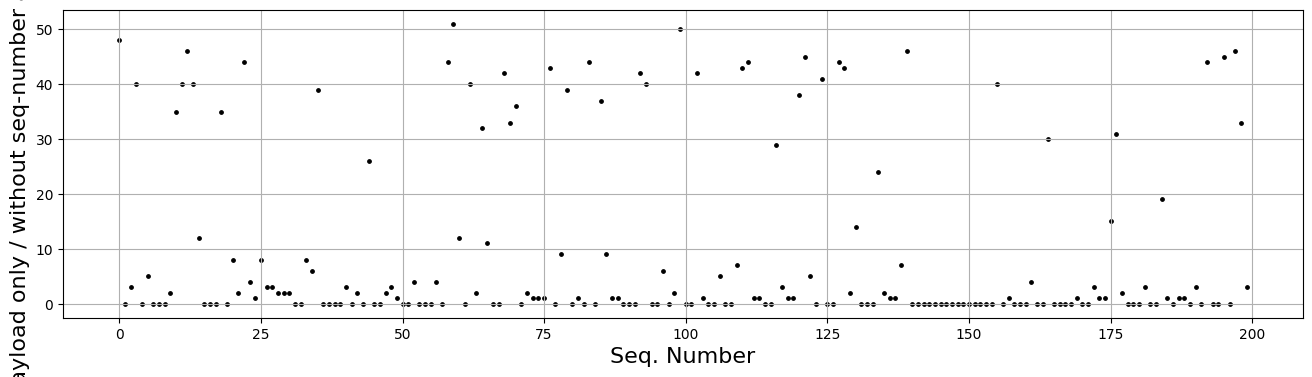

In [78]:
# BER for each packet
print("Note: if individual packets have a high bit-error rate, it could be that the pseudo-sequence number was corrupted and the script could not identify the expected payload correctly.")
plt.scatter(range(len(df)), [compute_ber_packet(row,PACKET_LEN=NUM_16RND*2)[0] for (_,row) in df.iterrows()], marker='o', s=6, color='black')
plt.grid()
plt.ylabel('Bit Error Rate [%] (payload only / without seq-number and pseudo-seq-number)', fontsize=16)
plt.xlabel('Seq. Number', fontsize=16)

# Distance

## Definition

**The communication distance of the system.**
<br>$D_{1}$: the distance between carrier<->backscatter_tag[m]
<br>$D_{2}$: the distance between backscatter_tag<->receiver[m]
<br> Distance metric = $D_{1}^2D_{2}^2$
<br>

In [79]:
# record the distance
dis_carrier_tag = 1
dis_tag_rx = 4

dis_metric = dis_carrier_tag**2*dis_tag_rx**2
print(f"Distance metric is: {dis_metric}")

Distance metric is: 16


# Radarplot

**Please pay attention to the unit**
<br> <font color='red'>Time</font>: use second as unit
<br> <font color='red'>Reliability</font>: use the percent as unit
<br> <font color='red'>Distance</font>: use meter as unit
<br>**Metics = [Time(s), Reliability(%), Distance(m)]**
<br> <font color='red'>Always keep the reference in your plot.</font>
<br> Tips: for ploting, time metric uses $\frac{1}{Time}*1000$ as the time metric, the higher the value the better the system performance

[np.float64(121.055), 91.36607142857143, 16]


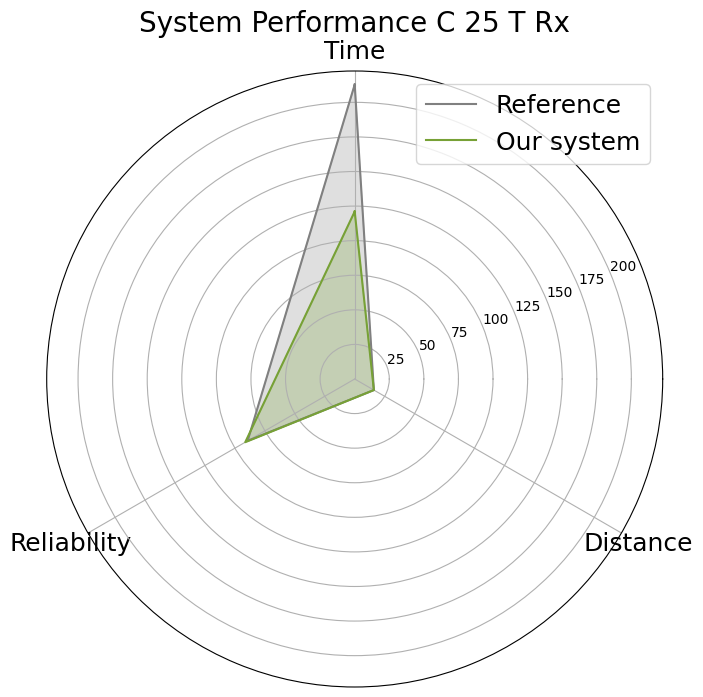

In [80]:
metrics = [file_delay_s, bit_reliability, dis_metric]

system_ref_baseline_c25 = [57.284, 96.41, 16] # C ->(25cm) Tag
system_ref_baseline_c50 = [np.float64(100.318), 92.21428571428572, 16] # C ->(50cm) Tag
system_ref_baseline_middle = [0, 0, 0] # C -> (150) Tag -> (150) Receiver
system_ref_baseline_rx50 = [np.float64(212.826), 89.36160714285715, 16] # Tag ->(50cm) Receiver
system_ref_baseline_rx25 = [np.float64(121.055), 91.36607142857143, 16] # # Tag ->(25cm) Receiver


print(metrics)
#                                                 25cm                            3m
title = "System Performance C 25 T Rx" # Carrier ------> Tag -> Receiver (Carrier --> Receiver)
radar_plot(metrics, system_ref=system_ref_baseline_rx50, title=title)